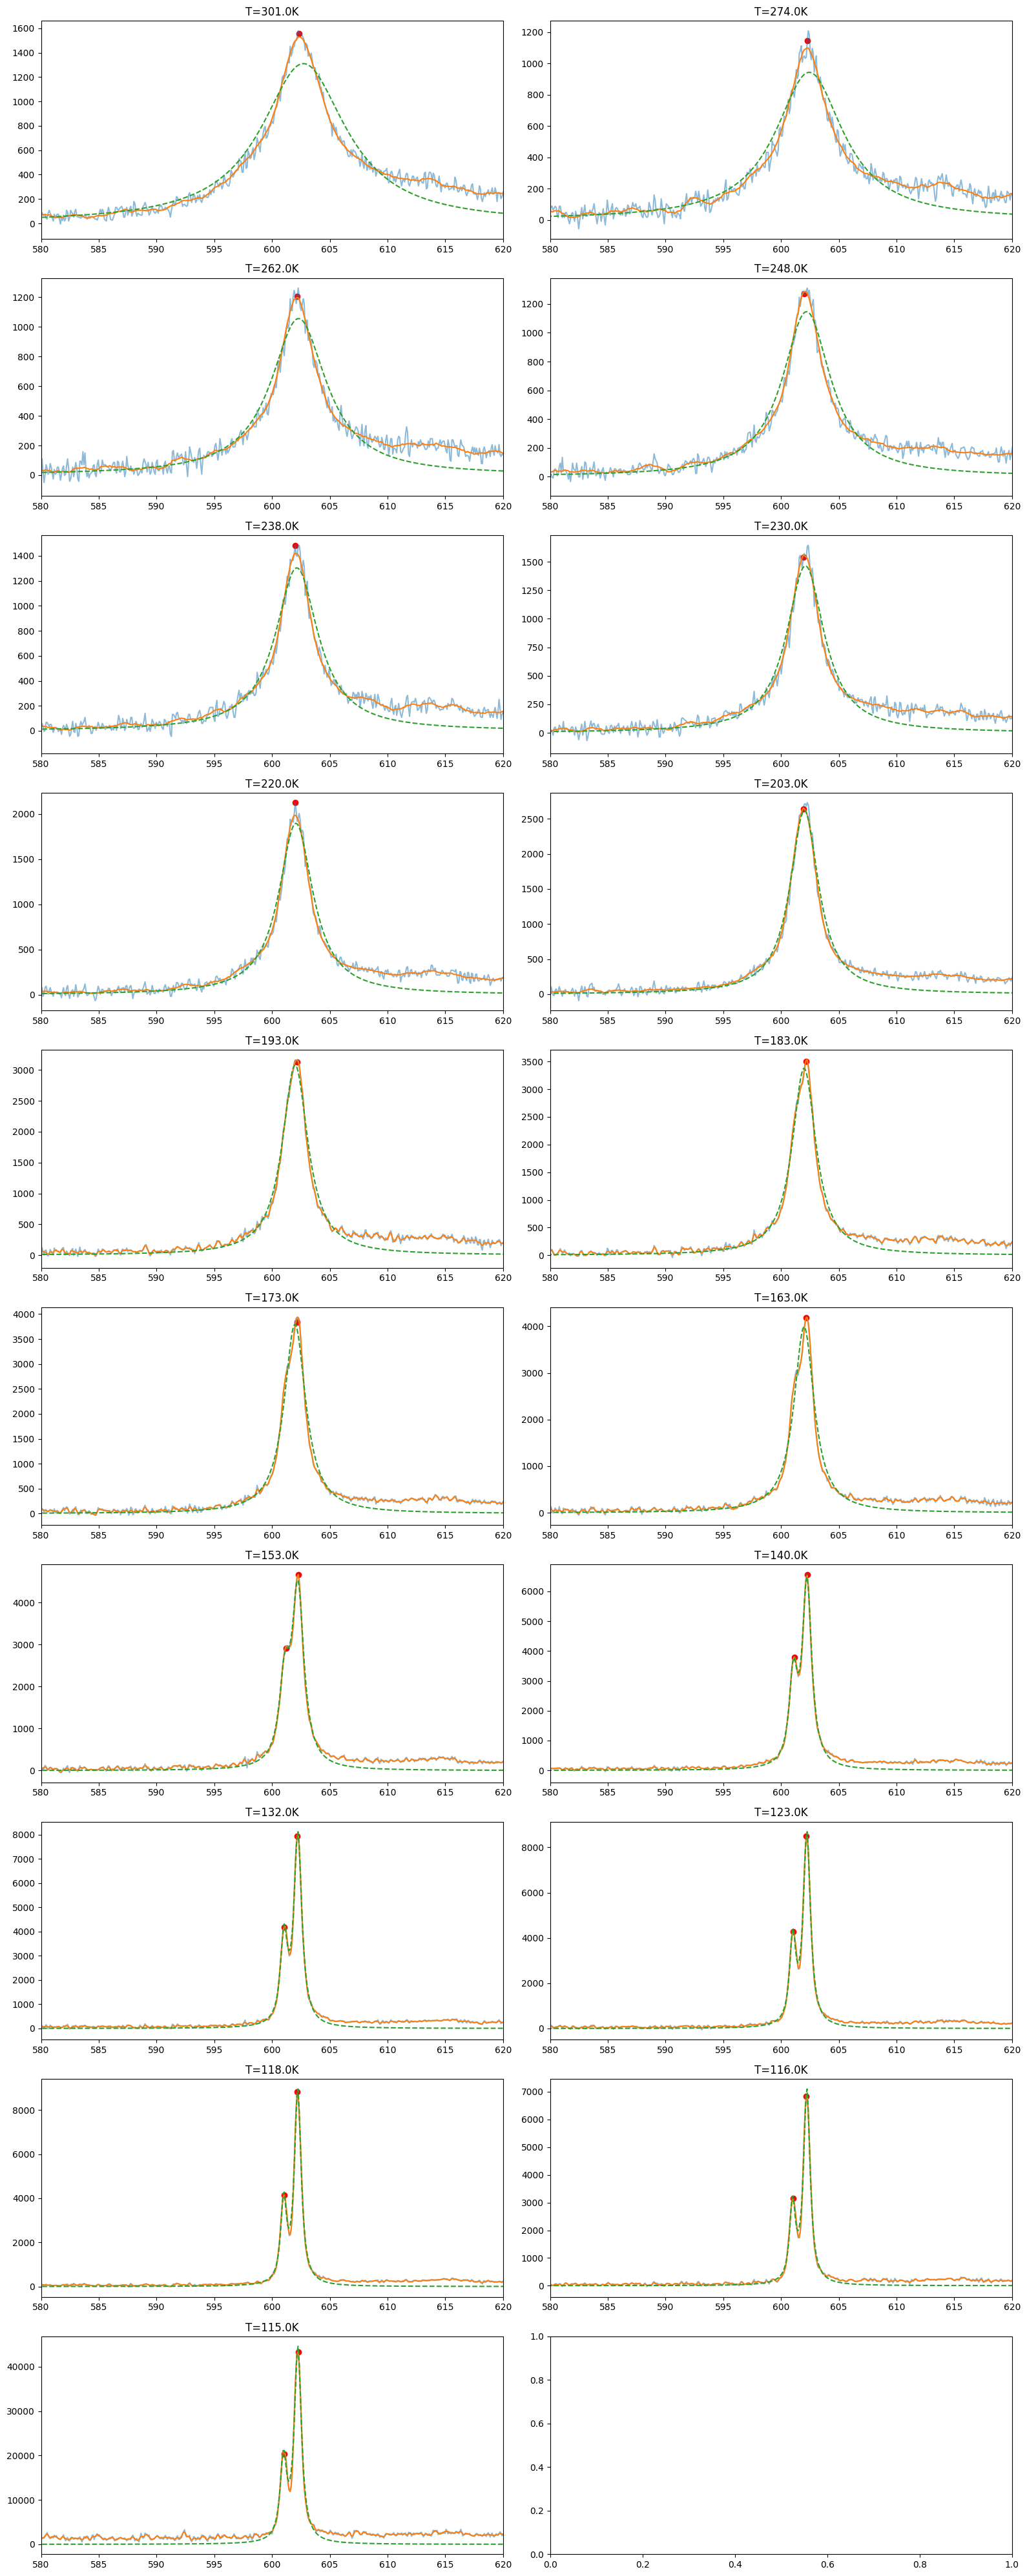

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy.optimize import curve_fit
from scipy.signal import find_peaks, savgol_filter


# ============================
# Peak class
# ============================

class Peak:

    def __init__(self, center, width, amplitude, T):

        self.center = center
        self.width = width
        self.amplitude = amplitude
        self.T = T


# ============================
# Lorentzian
# ============================

def lorentzian(x, A, x0, gamma):
    return A * gamma**2 / ((x - x0)**2 + gamma**2)


def double_lorentzian(x, A1, x01, g1, A2, x02, g2):
    return (
        lorentzian(x, A1, x01, g1)
        + lorentzian(x, A2, x02, g2)
    )


# ============================
# Temperature fit
# ============================

def T3_fit(T, a, b):
    return a + b * T**3


# ============================
# Measurement class
# ============================

class Measurement:

    def __init__(
        self,
        T,
        fit_range=(550,650),
        peak_height=0.3,
        peak_distance=5,
        smooth_window=31,
        smooth_poly=3
    ):

        self.T_raw = T
        self.T = T + 273

        self.data = pd.read_csv(f"parsed_data/data_{-T}.esp", sep=" ")

        self.fit_range = fit_range
        self.peak_height = peak_height
        self.peak_distance = peak_distance
        self.smooth_window = smooth_window
        self.smooth_poly = smooth_poly

        mask = (
            (self.data["lambda"] > fit_range[0]) &
            (self.data["lambda"] < fit_range[1])
        )

        self.data = self.data[mask]

        self.peak = None
        self.peak1 = None
        self.peak2 = None

        self.peaks = []

        self.peaks_idx = None
        self.y_smooth = None


    def fit(self):

        x = self.data["lambda"].values
        y = self.data["I"].values

        y_smooth = savgol_filter(
            y,
            self.smooth_window,
            self.smooth_poly
        )

        self.y_smooth = y_smooth

        peaks, _ = find_peaks(
            y_smooth,
            distance=self.peak_distance
        )

        threshold = np.max(y) * self.peak_height
        peaks = peaks[y[peaks] > threshold]

        if len(peaks) > 0:
            order = np.argsort(y[peaks])[::-1]
            peaks = peaks[order]

        self.peaks_idx = peaks

        # ============================
        # double fit
        # ============================

        if len(peaks) >= 2:

            p1 = peaks[0]
            p2 = peaks[1]

            A1 = y[p1]
            x01 = x[p1]

            A2 = y[p2]
            x02 = x[p2]

            gamma0 = 0.5

            try:

                popt, _ = curve_fit(
                    double_lorentzian,
                    x,
                    y,
                    p0=[A1, x01, gamma0, A2, x02, gamma0],
                    maxfev=20000
                )

                A1, x01, g1, A2, x02, g2 = popt

                self.peak1 = Peak(x01, g1, A1, self.T)
                self.peak2 = Peak(x02, g2, A2, self.T)

                self.peaks = [self.peak1, self.peak2]

                return

            except:
                pass

        # ============================
        # single fit
        # ============================

        A0 = np.max(y)
        x0 = x[np.argmax(y)]
        gamma0 = 1

        popt, _ = curve_fit(
            lorentzian,
            x,
            y,
            p0=[A0, x0, gamma0],
            maxfev=20000
        )

        A, x0, g = popt

        self.peak = Peak(x0, g, A, self.T)

        self.peaks = [self.peak]


    def plot_debug(self, ax, plot_range=None):

        x = self.data["lambda"].values
        y = self.data["I"].values

        ax.plot(x, y, alpha=0.5)

        if self.y_smooth is not None:
            ax.plot(x, self.y_smooth)

        if self.peaks_idx is not None:
            ax.scatter(
                x[self.peaks_idx],
                y[self.peaks_idx],
                color="red"
            )

        # fit
        if self.peaks:

            x_fit = np.linspace(x.min(), x.max(), 1000)

            if len(self.peaks) == 1:

                p = self.peaks[0]
                y_fit = lorentzian(
                    x_fit,
                    p.amplitude,
                    p.center,
                    p.width
                )

            else:

                p1, p2 = self.peaks

                y_fit = (
                    lorentzian(
                        x_fit,
                        p1.amplitude,
                        p1.center,
                        p1.width
                    )
                    +
                    lorentzian(
                        x_fit,
                        p2.amplitude,
                        p2.center,
                        p2.width
                    )
                )

            ax.plot(x_fit, y_fit, "--")

        if plot_range:
            ax.set_xlim(plot_range)

        ax.set_title(f"T={self.T:.1f}K")


# ============================
# Temperatures
# ============================

Ts = [
    28, 1, -11, -25, -35, -43, -53,
    -70, -80, -90, -100, -110, -120,
    -133, -141, -150, -155, -157, -158
]


# можно настраивать для каждого измерения
measurements = [
    Measurement(
        T,
        fit_range=(550,650),
        peak_height=0.4,     # удобно крутить
        peak_distance=1,
        smooth_window=7
    )
    for T in Ts
]



# ============================
# FIT
# ============================

for m in measurements:
    if(m.T > 200):
        m.smooth_window = 30
    m.fit()


# ============================
# Plot debug
# ============================

plots_per_fig = 20

for i in range(0, len(measurements), plots_per_fig):

    fig, axs = plt.subplots(10, 2, figsize=(16,40))
    axs = axs.flatten()

    for j in range(plots_per_fig):

        if i+j >= len(measurements):
            break

        measurements[i+j].plot_debug(
            axs[j],
            plot_range=(580,620)
        )

    plt.tight_layout()

plt.savefig("debug_plots.png", dpi=300)
plt.show()

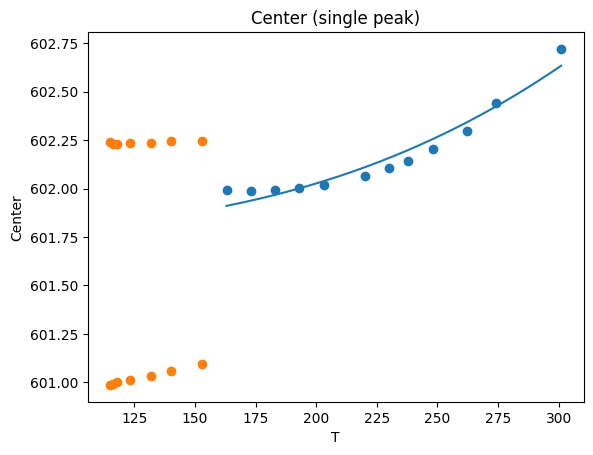

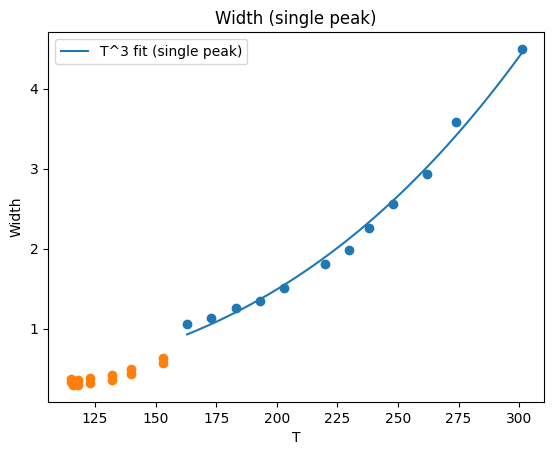

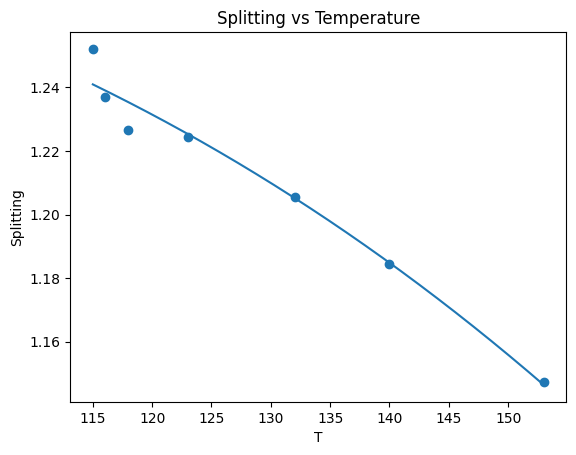

In [2]:
# ============================
# Collect peaks
# ============================

single_peaks = []
double_peaks = []
splitting_T = []
splitting_val = []

for m in measurements:

    if len(m.peaks) == 1:

        single_peaks.append(m.peaks[0])

    if len(m.peaks) == 2:

        double_peaks += m.peaks

        p1, p2 = m.peaks

        splitting_T.append(m.T)
        splitting_val.append(abs(p1.center - p2.center))


# ============================
# Plots
# ============================

T_single = [p.T for p in single_peaks]
center_single = [p.center for p in single_peaks]
width_single = [p.width for p in single_peaks]

T_double = [p.T for p in double_peaks]
center_double = [p.center for p in double_peaks]
width_double = [p.width for p in double_peaks]

T_single_arr = np.array(T_single)
center_single_arr = np.array(center_single)
width_single_arr = np.array(width_single)

width_fit, _ = curve_fit(T3_fit, T_single_arr, width_single_arr)
centre_fit, _ = curve_fit(T3_fit, T_single_arr, center_single_arr)
T_single_fit = np.linspace(T_single_arr.min(), T_single_arr.max(), 200)




plt.figure()
plt.scatter(T_single, center_single)
plt.scatter(T_double, center_double)
plt.plot(T_single_fit, T3_fit(T_single_fit, *centre_fit), label="T^3 fit (single peak)")
plt.title("Center (single peak)")
plt.xlabel("T")
plt.ylabel("Center")
plt.savefig("center_plot.png", dpi=300)
plt.show()


plt.figure()
plt.scatter(T_single, width_single)
plt.scatter(T_double, width_double)
plt.plot(T_single_fit, T3_fit(T_single_fit, *width_fit), label="T^3 fit (single peak)")
plt.title("Width (single peak)")
plt.xlabel("T")
plt.ylabel("Width")
plt.legend()
plt.savefig("width_plot.png", dpi=300)
plt.show()


# ============================
# Splitting
# ============================

if len(splitting_T) > 2:

    splitting_T = np.array(splitting_T)
    splitting_val = np.array(splitting_val)

    fit, _ = curve_fit(T3_fit, splitting_T, splitting_val)

    plt.figure()
    plt.scatter(splitting_T, splitting_val)

    T_fit = np.linspace(
        splitting_T.min(),
        splitting_T.max(),
        200
    )

    plt.plot(T_fit, T3_fit(T_fit, *fit))

    plt.title("Splitting vs Temperature")
    plt.xlabel("T")
    plt.ylabel("Splitting")

    plt.savefig("splitting_plot.png", dpi=300)
    plt.show()